# that-way — Synthetic Data Generator

Generates realistic synthetic data mirroring the Supabase schema for building and testing the preference learning model.

**Four users, each with a distinct hidden driving preference:**

| User | Archetype | Core preference |
|------|-----------|----------------|
| slowpoke | Highway Avoider | Residential streets only, avoids highways if possible |
| rightytighty | Left Turn Avoider | Will take a longer route to avoid left turns |
| trackstar | Speed Optimizer | Always fastest route; loves highways, hates slow streets |
| notyou | U-Turn Avoider | Will go past destination if it means avoiding a U-turn |

**Output DataFrames:** `df_users`, `df_known_places`, `df_frequented_routes`, `df_trips`, `df_route_steps`, `df_step_feedback`, `df_road_segment_preferences`

In [89]:
%pip install pandas numpy matplotlib seaborn scikit-learn --quiet


Note: you may need to restart the kernel to use updated packages.


In [90]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import uuid, random, json
from collections import defaultdict

np.random.seed(42)
random.seed(42)

START_DATE = datetime(2024, 10, 1)
END_DATE   = datetime(2024, 12, 31)

def uid():
    return str(uuid.uuid4())

## 1. User Preference Profiles (Ground Truth)

These are the **hidden** profiles that drive data generation. The model's job is to infer them from feedback.

notyou's u-turn avoidance is notable: their `left_turn_prob` is elevated (0.28 vs ~0.20 baseline) because they deliberately overshoot and use two left turns as a substitute when a u-turn would otherwise appear.

Users can have preferences for different road types. Road types can be classified by the following traits:

| Road Types | Description | 
|------|-----------|
| residential | quiet residential/neighborhood streets with not much traffic (~25mph speed limit) |
| arterial | major surface streets between neighborhoods (think something like irvine bake pkwy with ~45mph speed limit) |
| highway | controlled-access freeways with entrances/exits, high speed, and no intersections (~60-80mph) |
| local | roads that don't fit the above descriptions: service roads, alleys, parking lot access roads, etc (20-45mph) |

In [91]:
PROFILES = {
    'slowpoke': {
        'display_name': 'slowpoke',
        'archetype': 'Highway Avoider',
        'description': 'Prefers residential streets, avoids highways at all costs',
        'avoids_highways':    True,
        'avoids_left_turns':  False,
        'avoids_u_turns':     False,
        'prefers_fastest':    False,
        'prefers_residential':True,
        'highway_dislike_rate':     0.75,
        'left_turn_dislike_rate':   0.12,
        'uturn_dislike_rate':       0.10,
        'residential_like_rate':    0.30,
        'slow_road_dislike_rate':   0.05,
        'route_weights': {
            'road_types':    {'residential': 0.55, 'arterial': 0.35, 'highway': 0.05, 'local': 0.05},
            'left_turn_prob': 0.22,
            'uturn_prob':     0.04,
        },
    },
    'rightytighty': {
        'display_name': 'rightytighty',
        'archetype': 'Left Turn Avoider',
        'description': 'Will take longer routes to avoid left turns; fine with highways',
        'avoids_highways':    False,
        'avoids_left_turns':  True,
        'avoids_u_turns':     False,
        'prefers_fastest':    False,
        'prefers_residential':False,
        'highway_dislike_rate':     0.08,
        'left_turn_dislike_rate':   0.72,
        'uturn_dislike_rate':       0.10,
        'residential_like_rate':    0.08,
        'slow_road_dislike_rate':   0.10,
        'route_weights': {
            'road_types':    {'residential': 0.20, 'arterial': 0.45, 'highway': 0.25, 'local': 0.10},
            'left_turn_prob': 0.06,
            'uturn_prob':     0.04,
        },
    },
    'trackstar': {
        'display_name': 'trackstar',
        'archetype': 'Speed Optimizer',
        'description': 'Always fastest route; embraces highways, dislikes slow streets',
        'avoids_highways':    False,
        'avoids_left_turns':  False,
        'avoids_u_turns':     False,
        'prefers_fastest':    True,
        'prefers_residential':False,
        'highway_dislike_rate':     0.04,
        'left_turn_dislike_rate':   0.12,
        'uturn_dislike_rate':       0.10,
        'residential_like_rate':    0.04,
        'slow_road_dislike_rate':   0.68,
        'route_weights': {
            'road_types':    {'residential': 0.08, 'arterial': 0.28, 'highway': 0.50, 'local': 0.14},
            'left_turn_prob': 0.20,
            'uturn_prob':     0.04,
        },
    },
    'notyou': {
        'display_name': 'notyou',
        'archetype': 'U-Turn Avoider',
        'description': 'Will overshoot and take two left turns rather than make a U-turn',
        'avoids_highways':    False,
        'avoids_left_turns':  False,
        'avoids_u_turns':     True,
        'prefers_fastest':    False,
        'prefers_residential':False,
        'highway_dislike_rate':     0.08,
        'left_turn_dislike_rate':   0.10,
        'uturn_dislike_rate':       0.85,
        'residential_like_rate':    0.08,
        'slow_road_dislike_rate':   0.08,
        'route_weights': {
            'road_types':    {'residential': 0.30, 'arterial': 0.45, 'highway': 0.15, 'local': 0.10},
            'left_turn_prob': 0.28,
            'uturn_prob':     0.01,
        },
    },
}

users_data = [
    {'id': uid(), 'key': k,
     'created_at': START_DATE - timedelta(days=random.randint(30, 365)),
     'display_name': v['display_name']}
    for k, v in PROFILES.items()
]
df_users = pd.DataFrame(users_data)
user_id_map = dict(zip(df_users['key'], df_users['id']))

df_users[['id', 'display_name', 'created_at']]

,id,display_name,created_at
0,ebb8f857-9540-4499-8cf6-5c1991385a8f,slowpoke,2023-10-10
1,c2ba9ee6-9131-401d-a387-87952b33fa3e,rightytighty,2024-07-06
2,16172906-849e-42bc-ad40-fc728051e3f9,trackstar,2024-08-20
3,889c7719-5688-4da4-b855-705d1f93abbe,notyou,2024-04-14


## 2. Known Places

5–8 frequented locations per user, anchored to real areas within **Irvine, CA 92618** with small coordinate jitter.

In [92]:
# Real areas within Irvine 92618 with approximate centroid coordinates
IRVINE_AREAS = {
    'Woodbury':              (33.6985, -117.7362),  # residential, near Woodbury Town Center
    'Portola Springs':       (33.7080, -117.7478),  # residential, newer build area
    'Stonegate':             (33.7005, -117.7190),  # residential, near Jeffrey Rd
    'Cypress Village':       (33.6920, -117.7378),  # residential, near Great Park
    'Beacon Park':           (33.6895, -117.7480),  # residential, near Great Park Blvd
    'Great Park':            (33.6842, -117.7473),  # Great Park / retail / offices
    'Irvine Spectrum':       (33.6494, -117.7430),  # major retail / dining / entertainment
    'Sand Canyon':           (33.6750, -117.7610),  # Sand Canyon Ave corridor
    'Oak Creek':             (33.6850, -117.7280),  # residential + Oak Creek Golf Course
    'Spectrum Center':       (33.6510, -117.7435),  # Irvine Spectrum Center (shops/food)
    'Jeffrey Open Space':    (33.6950, -117.7265),  # trail / open space near Jeffrey Rd
    'Portola Center':        (33.6960, -117.7540),  # Portola Pkwy commercial strip
    'Laguna Altura':         (33.6430, -117.7550),  # gated community near 241 toll
    'UC Irvine':             (33.6405, -117.8443),  # UCI main campus (92697)
    'Irvine Valley College': (33.6492, -117.7744),  # IVC on Irvine Center Dr (92618)
}

def jitter(lat, lng, max_m=150):  # smaller jitter for denser Irvine grid
    dlat = random.uniform(-max_m, max_m) / 111_320
    dlng = random.uniform(-max_m, max_m) / (111_320 * np.cos(np.radians(lat)))
    return round(lat + dlat, 6), round(lng + dlng, 6)

PLACE_DEFS = {
    'slowpoke': [
        ('Home',          'Woodbury'),
        ('Work',          'Irvine Spectrum'),
        ('Coffee Shop',   'Woodbury'),
        ('Gym',           'Portola Center'),
        ('Grocery Store', 'Woodbury'),
        ('Mall',           'Irvine Spectrum'),
        ('Park',          'Jeffrey Open Space'),
        ('School',        'Irvine Valley College'),
    ],
    'rightytighty': [
        ('Home',           'Stonegate'),
        ('Work',           'Great Park'),
        ('Coffee Shop',    'Spectrum Center'),
        ('Gym',            'Portola Center'),
        ('Grocery Store',  'Stonegate'),
        ('Restaurant',     'Irvine Spectrum'),
        ("Friend's House", 'Cypress Village'),
    ],
    'trackstar': [
        ('Home',          'Portola Springs'),
        ('Work',          'Irvine Spectrum'),
        ('Coffee Shop',   'Spectrum Center'),
        ('Gym',           'Spectrum Center'),
        ('Grocery Store', 'Portola Center'),
        ('Restaurant',    'Irvine Spectrum'),
        ('Library',       'Portola Center'),
        ('Parents',       'Oak Creek'),
        ('School',        'UC Irvine'),
    ],
    'notyou': [
        ('Home',          'Beacon Park'),
        ('Work',          'Great Park'),
        ('Coffee Shop',   'Portola Center'),
        ('Gym',           'Cypress Village'),
        ('Grocery Store', 'Beacon Park'),
        ('Restaurant',    'Irvine Spectrum'),
        ('Park',          'Jeffrey Open Space'),
    ],
}

known_places_data = []
place_id_map = {}

for u in users_data:
    for label, hood in PLACE_DEFS[u['key']]:
        lat, lng = jitter(*IRVINE_AREAS[hood])
        pid = uid()
        place_id_map[(u['key'], label)] = pid
        known_places_data.append({
            'id': pid, 'user_id': u['id'], 'user_key': u['key'],
            'label': label, 'neighborhood': hood,
            'lat': lat, 'lng': lng,
            'radius_m': 50.0,
            'visit_count': 0,
            'last_visited': None,
        })

df_known_places = pd.DataFrame(known_places_data)
df_known_places.groupby('user_key')[['label', 'neighborhood', 'lat', 'lng']].apply(lambda g: g.reset_index(drop=True))

label           neighborhood        lat         lng
user_key                                                                    
notyou       0            Home            Beacon Park  33.689110 -117.747449
             1            Work             Great Park  33.684744 -117.746706
             2     Coffee Shop         Portola Center  33.694845 -117.753563
             3             Gym        Cypress Village  33.692092 -117.738627
             4   Grocery Store            Beacon Park  33.689398 -117.748745
             5      Restaurant        Irvine Spectrum  33.650546 -117.742391
             6            Park     Jeffrey Open Space  33.694244 -117.727069
rightytighty 0            Home              Stonegate  33.701495 -117.718162
             1            Work             Great Park  33.683283 -117.747551
             2     Coffee Shop        Spectrum Center  33.650401 -117.744422
             3             Gym         Portola Center  33.696710 -117.755288
             4   Grocery Store              Stonegate  33.700176 -117.719457
             5      Restaurant        Irvine Spectrum  33.648979 -117.743762
             6  Friend's House        Cypress Village  33.690770 -117.737931
slowpoke     0            Home               Woodbury  33.697813 -117.737368
             1            Work        Irvine Spectrum  33.648329 -117.742221
             2     Coffee Shop               Woodbury  33.698622 -117.735907
             3             Gym         Portola Center  33.694738 -117.755316
             4   Grocery Store               Woodbury  33.697780 -117.735870
             5            Mall        Irvine Spectrum  33.649565 -117.742301
             6            Park     Jeffrey Open Space  33.695543 -117.726761
             7          School  Irvine Valley College  33.649063 -117.775118
trackstar    0            Home        Portola Springs  33.706989 -117.746432
             1            Work        Irvine Spectrum  33.648265 -117.743670
             2     Coffee Shop        Spectrum Center  33.651347 -117.742252
             3             Gym        Spectrum Center  33.650627 -117.744496
             4   Grocery Store         Portola Center  33.694840 -117.753478
             5      Restaurant        Irvine Spectrum  33.650136 -117.741429
             6         Library         Portola Center  33.696958 -117.752813
             7         Parents              Oak Creek  33.684677 -117.728151
             8          School              UC Irvine  33.641400 -117.845392

In [93]:
import math
import seaborn as sns

def haversine_m(lat1, lng1, lat2, lng2):
    R = 6_371_000
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlam = math.radians(lng2 - lng1)
    a = math.sin(dphi/2)**2 + math.cos(phi1)*math.cos(phi2)*math.sin(dlam/2)**2
    return 2 * R * math.asin(math.sqrt(a))

DETOUR   = 1.35   # straight-line → driving distance factor for Irvine's grid
AVG_MPH  = 28     # effective average speed incl. signals / turns
AVG_MPS  = AVG_MPH * 0.44704

areas  = list(IRVINE_AREAS.keys())
coords = list(IRVINE_AREAS.values())

rows = []
for i, origin in enumerate(areas):
    lat1, lng1 = coords[i]
    for j, dest in enumerate(areas):
        if i == j:
            continue
        lat2, lng2 = coords[j]
        drive_m = haversine_m(lat1, lng1, lat2, lng2) * DETOUR
        drive_s = drive_m / AVG_MPS
        rows.append({
            'from': origin, 'to': dest,
            'drive_miles': round(drive_m / 1609.34, 2),
            'drive_min':   round(drive_s / 60, 1),
        })

df_area_distances = pd.DataFrame(rows)

print(f"Pairwise driving estimates — {DETOUR}x detour factor, {AVG_MPH} mph avg speed\n")
df_area_distances.set_index(['from', 'to'])

Pairwise driving estimates — 1.35x detour factor, 28 mph avg speed



drive_miles  drive_min
from                  to                                        
Woodbury              Portola Springs            1.26        2.7
                      Stonegate                  1.35        2.9
                      Cypress Village            0.62        1.3
                      Beacon Park                1.24        2.7
                      Great Park                 1.59        3.4
...                                               ...        ...
Irvine Valley College Spectrum Center            2.41        5.2
                      Jeffrey Open Space         5.66       12.1
                      Portola Center             4.64       10.0
                      Laguna Altura              1.61        3.5
                      UC Irvine                  5.49       11.8

[210 rows x 2 columns]

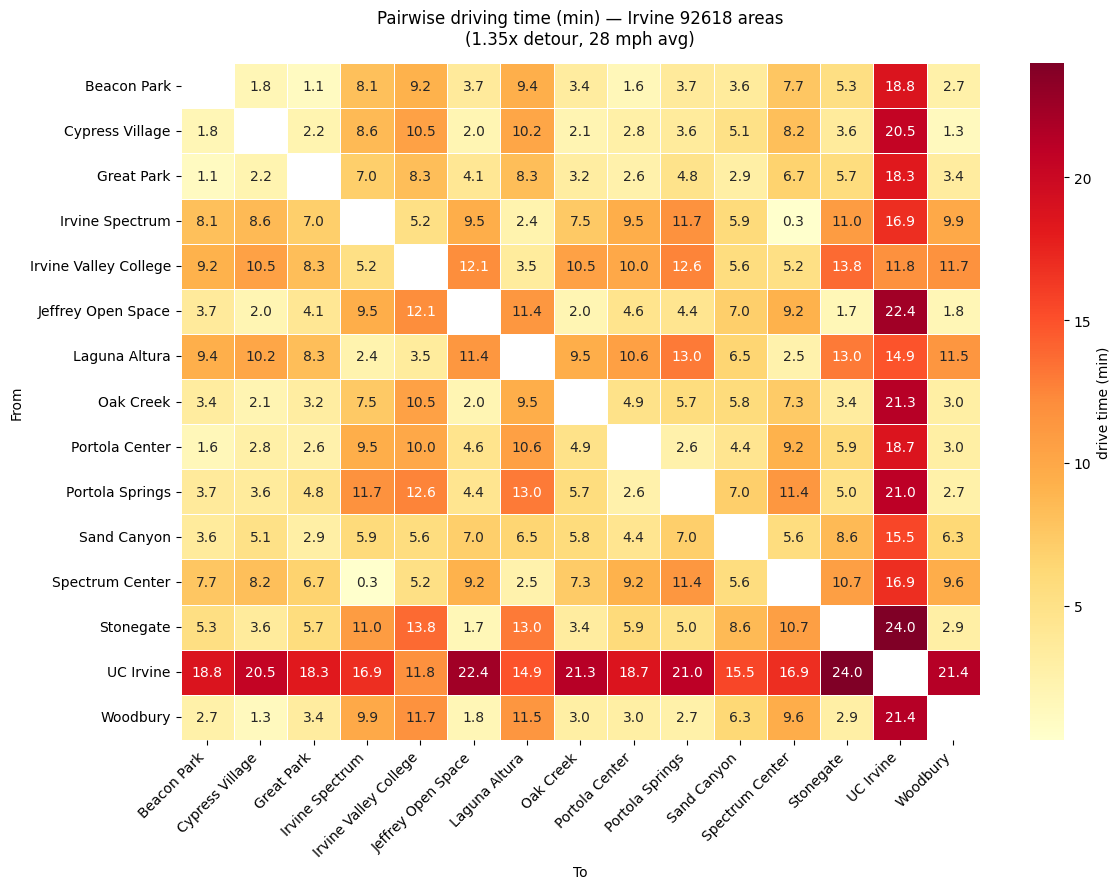

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df_area_distances.pivot(index='from', columns='to', values='drive_min')

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'drive time (min)'},
    ax=ax,
)
ax.set_title(f'Pairwise driving time (min) — Irvine 92618 areas\n({DETOUR}x detour, {AVG_MPH} mph avg)', pad=14)
ax.set_xlabel('To')
ax.set_ylabel('From')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Frequented Routes

One row per regular origin→destination pair per user. The `behavior_profile` JSONB captures the user's learned habits for that leg.

In [95]:
ROUTE_PAIRS = {
    'slowpoke':     [('Home','Work'), ('Work','Home'), ('Home','Grocery Store'),
                     ('Home','Gym'), ('Home','Coffee Shop'), ('Home','Mall'),
                     ('Home','School'), ('School','Home')],
    'rightytighty': [('Home','Work'), ('Work','Home'), ('Home','Grocery Store'),
                     ('Home','Gym'), ('Work','Coffee Shop'), ('Home','Restaurant')],
    'trackstar':    [('Home','Work'), ('Work','Home'), ('Home','Grocery Store'),
                     ('Home','Gym'), ('Home','Restaurant'), ('Home','Parents'),
                     ('Home','School'), ('School','Home')],
    'notyou':       [('Home','Work'), ('Work','Home'), ('Home','Grocery Store'),
                     ('Home','Gym'), ('Home','Coffee Shop'), ('Home','Restaurant')],
}

def make_behavior_profile(profile):
    rw = profile['route_weights']
    top_road_types = sorted(rw['road_types'], key=lambda k: -rw['road_types'][k])[:2]
    return {
        'avoids_highways':    profile['avoids_highways'],
        'avoids_left_turns':  profile['avoids_left_turns'],
        'avoids_u_turns':     profile['avoids_u_turns'],
        'prefers_residential':profile['prefers_residential'],
        'prefers_fastest':    profile['prefers_fastest'],
        'typical_road_types': top_road_types,
        'highway_step_pct':   round(rw['road_types']['highway'], 2),
        'left_turn_pct':      round(rw['left_turn_prob'], 2),
        'uturn_pct':          round(rw['uturn_prob'], 3),
        'avg_speed_preference': (
            0.85 if profile['prefers_fastest'] else
            0.30 if profile['avoids_highways'] else 0.55
        ),
    }

frequented_routes_data = []
fr_id_map = {}

for u in users_data:
    key = u['key']
    bp  = make_behavior_profile(PROFILES[key])
    for origin_lbl, dest_lbl in ROUTE_PAIRS[key]:
        oid = place_id_map.get((key, origin_lbl))
        did = place_id_map.get((key, dest_lbl))
        if not oid or not did:
            continue
        rid = uid()
        fr_id_map[(key, origin_lbl, dest_lbl)] = rid
        frequented_routes_data.append({
            'id': rid, 'user_id': u['id'], 'user_key': key,
            'origin_place_id': oid, 'dest_place_id': did,
            'origin_label': origin_lbl, 'dest_label': dest_lbl,
            'trip_count': 0,
            'distance_meters':  round(random.uniform(2_500, 14_000), 2),
            'duration_seconds': random.randint(600, 2_400),
            'behavior_profile': bp,
        })

df_frequented_routes = pd.DataFrame(frequented_routes_data)
print(f"{len(df_frequented_routes)} frequented routes across {df_frequented_routes['user_key'].nunique()} users")
df_frequented_routes[['user_key','origin_label','dest_label','distance_meters','duration_seconds']]

28 frequented routes across 4 users


,user_key,origin_label,dest_label,distance_meters,duration_seconds
0,slowpoke,Home,Work,11335.61,714
1,slowpoke,Work,Home,5134.05,665
2,slowpoke,Home,Grocery Store,11758.03,1421
3,slowpoke,Home,Gym,5579.02,1032
4,slowpoke,Home,Coffee Shop,13001.07,1761
5,slowpoke,Home,Mall,12578.23,1244
6,slowpoke,Home,School,4945.21,1622
7,slowpoke,School,Home,7049.77,1916
8,rightytighty,Home,Work,7776.80,1142
9,rightytighty,Work,Home,4105.75,2125


## 4. Trips — 90-Day Calendar

Weekday commutes (Home→Work morning, Work→Home evening) plus random extra trips. Trips linked to a `source_route_id` when the destination is a known frequented route.

In [96]:
EXTRAS = {
    'slowpoke':     [('Home','Coffee Shop'), ('Home','Gym'), ('Home','Grocery Store'),
                     ('Home','Mall'), ('Home','Park'), ('Home','School')],
    'rightytighty': [('Home','Coffee Shop'), ('Home','Gym'), ('Home','Grocery Store'),
                     ('Home','Restaurant'), ('Home',"Friend's House")],
    'trackstar':    [('Home','Coffee Shop'), ('Home','Gym'), ('Home','Grocery Store'),
                     ('Home','Restaurant'), ('Home','Parents'), ('Home','School')],
    'notyou':       [('Home','Coffee Shop'), ('Home','Gym'), ('Home','Grocery Store'),
                     ('Home','Restaurant'), ('Home','Park')],
}
EXTRA_PROB = {'slowpoke': 0.45, 'rightytighty': 0.40, 'trackstar': 0.50, 'notyou': 0.42}

# One-off destinations the app would auto-detect via background tracking --
# no known_place record, no frequented route, dest_place_id is null.
RANDOM_DESTS = {
    'slowpoke':     ['Hardware Store', 'Library', 'Post Office', 'Dentist',
                     'Car Wash', 'Pharmacy', 'Farmers Market', 'Bookstore'],
    'rightytighty': ['Hardware Store', 'Barber', 'Post Office', 'Bank',
                     'Car Wash', 'Pharmacy', 'Dry Cleaner', 'Urgent Care'],
    'trackstar':    ['Car Dealership', 'Sporting Goods', 'Auto Parts', 'Airport',
                     'Car Wash', 'Pharmacy', 'Urgent Care', 'Best Buy'],
    'notyou':       ['Hardware Store', 'Library', 'Post Office', 'Bank',
                     'Car Wash', 'Pharmacy', 'Dry Cleaner', 'Movie Theater'],
}
RANDOM_TRIP_PROB = {'slowpoke': 0.30, 'rightytighty': 0.28, 'trackstar': 0.35, 'notyou': 0.28}

def rand_offset(base_hour, spread_min=30):
    return timedelta(hours=base_hour, minutes=random.randint(-spread_min, spread_min))

def make_trip(u, origin_lbl, dest_lbl, started_at):
    key = u['key']
    oid = place_id_map.get((key, origin_lbl))
    did = place_id_map.get((key, dest_lbl))
    src = fr_id_map.get((key, origin_lbl, dest_lbl))
    return {
        'id': uid(), 'user_id': u['id'], 'user_key': key,
        'started_at': started_at,
        'ended_at':   started_at + timedelta(minutes=random.randint(12, 50)),
        'status': 'completed',
        'origin_label':    origin_lbl,
        'dest_label':      dest_lbl,
        'origin_place_id': oid,
        'dest_place_id':   did,
        'source_route_id': src,
        'is_frequented':   src is not None,
        'trip_type':       'commute' if src is not None and dest_lbl in ('Work', 'Home') else
                           'extra'   if did is not None else
                           'random',
    }

trips_data = []
day = START_DATE
while day <= END_DATE:
    dow = day.weekday()
    for u in users_data:
        k = u['key']
        if dow < 5:
            trips_data.append(make_trip(u, 'Home', 'Work', day + rand_offset(8, 30)))
            trips_data.append(make_trip(u, 'Work', 'Home', day + rand_offset(17, 45)))
        # Structured extras (known destinations)
        if random.random() < EXTRA_PROB[k]:
            pair = random.choice(EXTRAS[k])
            base = 13 if dow >= 5 else 19
            trips_data.append(make_trip(u, pair[0], pair[1], day + rand_offset(base, 90)))
        # Background-detected random trips (novel destinations, no known_place)
        if random.random() < RANDOM_TRIP_PROB[k]:
            dest = random.choice(RANDOM_DESTS[k])
            origin = 'Work' if dow < 5 and random.random() < 0.25 else 'Home'
            hour = random.randint(9, 20)
            trips_data.append(make_trip(u, origin, dest, day + rand_offset(hour, 60)))
    day += timedelta(days=1)

df_trips = pd.DataFrame(trips_data)

tc = df_trips[df_trips['source_route_id'].notna()].groupby('source_route_id').size()
df_frequented_routes['trip_count'] = df_frequented_routes['id'].map(tc).fillna(0).astype(int)

arrivals = df_trips.groupby('dest_place_id').agg(
    visit_count=('id','count'), last_visited=('ended_at','max')
).reset_index().rename(columns={'dest_place_id':'id'})
df_known_places = df_known_places.merge(arrivals, on='id', how='left', suffixes=('','_new'))
df_known_places['visit_count'] = df_known_places['visit_count_new'].fillna(0).astype(int)
df_known_places['last_visited'] = df_known_places['last_visited_new']
df_known_places.drop(columns=['visit_count_new','last_visited_new'], inplace=True)

summary = df_trips.groupby('user_key').agg(
    total=('id','count'),
    commute=('trip_type', lambda x: (x=='commute').sum()),
    extra=('trip_type',   lambda x: (x=='extra').sum()),
    random=('trip_type',  lambda x: (x=='random').sum()),
)
print(summary)
print(f"\nTotal trips: {len(df_trips)}")


              total  commute  extra  random
user_key                                   
notyou          194      132     38      24
rightytighty    198      132     38      28
slowpoke        205      132     50      23
trackstar       201      132     44      25

Total trips: 798


## 5. Route Steps

Each trip gets 6–14 turn-by-turn steps. **For frequented routes, 80% of segment IDs are reused across trips** (canonical pool per place pair), so `road_segment_preferences` accumulates meaningful traversal counts.

Key per-user signals baked into the distribution:
- **slowpoke**: mostly residential/arterial, ~5% highway steps
- **rightytighty**: ~6% left-turn steps (routes around them), normal highway use
- **trackstar**: ~50% highway steps, sparse residential
- **notyou**: ~1% u-turn steps, elevated left-turn share (~28%) as the deliberate substitute

In [97]:
CANONICAL_SEGS = {}

RIGHT_TURN_BAND     = 0.30   # probability mass for right-turn maneuvers
HIGHWAY_MERGE_BAND  = 0.50   # additional mass for merge/ramp on highway steps
SEGMENT_REUSE_PROB  = 0.80   # chance a frequented-route step reuses a canonical segment

def get_canonical_segs(user_key, origin_lbl, dest_lbl, n=16):
    k = (user_key, origin_lbl, dest_lbl)
    if k not in CANONICAL_SEGS:
        CANONICAL_SEGS[k] = [f"way/{random.randint(100_000_000, 999_999_999)}" for _ in range(n)]
    return CANONICAL_SEGS[k]

SPEED_LIMITS = {'residential': [20,25,25,30], 'arterial': [35,40,45], 'highway': [55,65,65], 'local': [15,20,25]}


def pick_maneuver(roll, left_turn_prob, uturn_prob, is_highway):
    if roll < uturn_prob:
        return 'u_turn', False, True
    if roll < uturn_prob + left_turn_prob:
        return random.choice(['turn_left', 'turn_slight_left']), True, False
    if roll < uturn_prob + left_turn_prob + RIGHT_TURN_BAND:
        return random.choice(['turn_right', 'turn_slight_right']), False, False
    if is_highway and roll < uturn_prob + left_turn_prob + HIGHWAY_MERGE_BAND:
        return random.choice(['merge', 'ramp']), False, False
    return 'straight', False, False


def pick_segment_id(pool, i):
    if pool and i < len(pool) and random.random() < SEGMENT_REUSE_PROB:
        return pool[i % len(pool)]
    return f"way/{random.randint(100_000_000, 999_999_999)}"


def generate_steps(trip):
    user_key       = trip['user_key']
    profile        = PROFILES[user_key]
    route_weights  = profile['route_weights']
    road_types     = list(route_weights['road_types'].keys())
    road_weights   = list(route_weights['road_types'].values())
    left_turn_prob = route_weights['left_turn_prob']
    uturn_prob     = route_weights['uturn_prob']
    n_steps        = random.randint(6, 14)
    pool = get_canonical_segs(user_key, trip['origin_label'], trip['dest_label']) if trip['is_frequented'] else None
    steps = []
    for i in range(n_steps):
        road_type  = random.choices(road_types, weights=road_weights)[0]
        is_highway = (road_type == 'highway')
        if i == 0:
            maneuver, is_left_turn, is_u_turn = 'depart', False, False
        elif i == n_steps - 1:
            maneuver, is_left_turn, is_u_turn = 'arrive', False, False
        else:
            maneuver, is_left_turn, is_u_turn = pick_maneuver(
                random.random(), left_turn_prob, uturn_prob, is_highway
            )
        speed = random.choice(SPEED_LIMITS[road_type])
        dist  = random.uniform(
            800 if is_highway else (150 if road_type == 'arterial' else 50),
            6000 if is_highway else (1500 if road_type == 'arterial' else 400)
        )
        dur = dist / (speed * 0.44704)
        steps.append({
            'id': uid(), 'trip_id': trip['id'], 'user_key': user_key,
            'step_index': i, 'segment_id': pick_segment_id(pool, i), 'maneuver': maneuver,
            'road_type': road_type, 'is_highway': is_highway,
            'is_left_turn': is_left_turn, 'is_u_turn': is_u_turn,
            'distance_meters': round(dist, 2), 'duration_seconds': int(dur),
            'speed_limit_mph': speed,
            'attributes': json.dumps({'road_type': road_type, 'is_highway': is_highway,
                                      'is_left_turn': is_left_turn, 'is_u_turn': is_u_turn,
                                      'speed_limit_mph': speed}),
        })
    return steps

route_steps_data = []
for trip in df_trips.to_dict('records'):
    route_steps_data.extend(generate_steps(trip))

df_route_steps = pd.DataFrame(route_steps_data)
non_terminal = df_route_steps[~df_route_steps['maneuver'].isin(['depart','arrive'])]
print(f"Total steps: {len(df_route_steps)}")
print("\nRoute character by user (non-terminal steps):")
non_terminal.groupby('user_key')[['is_highway','is_left_turn','is_u_turn']].mean().round(3).rename(
    columns={'is_highway':'highway_share','is_left_turn':'left_turn_share','is_u_turn':'uturn_share'}
)


Total steps: 8075

Route character by user (non-terminal steps):


,highway_share,left_turn_share,uturn_share
user_key,,,
notyou,0.141,0.284,0.011
rightytighty,0.246,0.067,0.048
slowpoke,0.047,0.220,0.040
trackstar,0.515,0.195,0.046


## 6. Step Feedback

Post-trip feedback on individual steps. ~50% of trips receive any feedback. When feedback is given:
- Steps violating a user's preference → **disliked** at that user's configured dislike rate
- Steps matching a preference → **liked** at a lower rate
- Noise baked in throughout

In [98]:
steps_by_trip = defaultdict(list)
for s in route_steps_data:
    steps_by_trip[s['trip_id']].append(s)

def feedback_for_trip(trip, steps):
    if random.random() > 0.50:
        return []
    key, profile, events = trip['user_key'], PROFILES[trip['user_key']], []
    for s in steps:
        if s['maneuver'] in ('depart', 'arrive'):
            continue
        sentiment = None
        if profile['avoids_highways'] and s['is_highway']:
            if random.random() < profile['highway_dislike_rate']:
                sentiment = 'disliked'
        if sentiment is None and profile['avoids_left_turns'] and s['is_left_turn']:
            if random.random() < profile['left_turn_dislike_rate']:
                sentiment = 'disliked'
        if sentiment is None and profile['avoids_u_turns'] and s['is_u_turn']:
            if random.random() < profile['uturn_dislike_rate']:
                sentiment = 'disliked'
        if sentiment is None and profile['prefers_fastest'] and s['road_type'] == 'residential':
            if random.random() < profile['slow_road_dislike_rate']:
                sentiment = 'disliked'
        if sentiment is None:
            if profile['prefers_residential'] and s['road_type'] == 'residential':
                if random.random() < profile['residential_like_rate']:
                    sentiment = 'liked'
            elif profile['prefers_fastest'] and s['is_highway']:
                if random.random() < 0.20:
                    sentiment = 'liked'
        if sentiment:
            events.append({'id': uid(), 'step_id': s['id'], 'segment_id': s['segment_id'],
                           'user_id': trip['user_id'], 'user_key': key, 'trip_id': trip['id'],
                           'created_at': trip['ended_at'], 'sentiment': sentiment,
                           'road_type': s['road_type'], 'is_highway': s['is_highway'],
                           'is_left_turn': s['is_left_turn'], 'is_u_turn': s['is_u_turn'],
                           'note': None})
    return events

step_feedback_data = []
for trip in df_trips.to_dict('records'):
    step_feedback_data.extend(feedback_for_trip(trip, steps_by_trip[trip['id']]))

df_step_feedback = pd.DataFrame(step_feedback_data)
print(f"Total feedback events: {len(df_step_feedback)}")
print(f"Trips with feedback:   {df_step_feedback['trip_id'].nunique()} / {len(df_trips)}")
print()
df_step_feedback.groupby(['user_key','sentiment'])['id'].count().unstack(fill_value=0)

Total feedback events: 363
Trips with feedback:   194 / 798



sentiment,disliked,liked
user_key,,
notyou,6,0
rightytighty,45,0
slowpoke,37,136
trackstar,51,88


## 7. Road Segment Preferences (Derived)

Aggregated from route steps (traversal counts) + step feedback (liked/disliked counts). One row per `(user, segment_id)` — mirrors the `road_segment_preferences` DB table.

In [99]:
traversals = (
    df_route_steps[~df_route_steps['maneuver'].isin(['depart','arrive'])]
    .groupby(['user_key','segment_id'])
    .agg(times_traversed=('id','count'), road_type=('road_type','first'),
         is_highway=('is_highway','first'), is_left_turn=('is_left_turn','first'),
         is_u_turn=('is_u_turn','first'), maneuver=('maneuver','first'))
    .reset_index()
)
if len(df_step_feedback) > 0:
    fb_counts = (
        df_step_feedback.groupby(['user_key','segment_id','sentiment'])['id']
        .count().unstack(fill_value=0).reset_index()
    )
    for col in ('liked','disliked'):
        if col not in fb_counts.columns:
            fb_counts[col] = 0
    fb_counts = fb_counts.rename(columns={'liked':'times_liked','disliked':'times_disliked'})
else:
    fb_counts = traversals[['user_key','segment_id']].copy()
    fb_counts['times_liked'] = fb_counts['times_disliked'] = 0

df_rsp = (
    traversals
    .merge(fb_counts[['user_key','segment_id','times_liked','times_disliked']],
           on=['user_key','segment_id'], how='left')
    .fillna({'times_liked':0,'times_disliked':0})
)
df_rsp['times_liked']    = df_rsp['times_liked'].astype(int)
df_rsp['times_disliked'] = df_rsp['times_disliked'].astype(int)

def derive_signal(r):
    if r['times_disliked'] > r['times_liked'] and r['times_disliked'] > 0: return 'negative'
    if r['times_liked'] > r['times_disliked'] and r['times_liked'] > 0:    return 'positive'
    return 'neutral'

df_rsp['signal']     = df_rsp.apply(derive_signal, axis=1)
df_rsp['context']    = df_rsp.apply(lambda r: json.dumps({'road_type': r['road_type'],
    'maneuver': r['maneuver'], 'is_highway': bool(r['is_highway']),
    'is_left_turn': bool(r['is_left_turn']), 'is_u_turn': bool(r['is_u_turn'])}), axis=1)
df_rsp['id']         = [uid() for _ in range(len(df_rsp))]
df_rsp['user_id']    = df_rsp['user_key'].map(user_id_map)
df_rsp['updated_at'] = END_DATE
df_road_segment_preferences = df_rsp

print(f"Total road_segment_preference rows: {len(df_road_segment_preferences):,}")
print()
df_road_segment_preferences.groupby(['user_key','signal'])['id'].count().unstack(fill_value=0)

Total road_segment_preference rows: 2,434



signal,negative,neutral,positive
user_key,,,
notyou,6,574,0
rightytighty,33,591,0
slowpoke,15,530,61
trackstar,29,536,59


## 8. Summary — Ground Truth vs Inferred Preferences

How well can we recover each user's hidden preference profile from their feedback data alone?

Note on **notyou**: u-turn steps are rare in their routes (~1%) so the raw count of disliked u-turn steps is small. The signal still comes through because the dislike *rate* on the few u-turns that appear is very high (~85%). A real model would also use the *absence* of u-turns in frequented routes as a strong prior.

Inferred preferences are calculated by tallying each segment and then applying cutoffs for the boolean. This is compared against the ground-truth pipeline.


In [100]:
HW_DISLIKE_THRESHOLD   = 0.15
LT_DISLIKE_THRESHOLD   = 0.15
UT_DISLIKE_THRESHOLD   = 0.20
UT_RARE_SHARE          = 0.015   # if u-turns are this rare in routes...
UT_RARE_DISLIKE_FLOOR  = 0.10    # ...a lower dislike rate still implies avoidance
RES_LIKE_THRESHOLD     = 0.06
HW_LIKE_THRESHOLD      = 0.08
HW_FAST_SHARE_FLOOR    = 0.30

def check(truth, inferred):
    return '✓' if truth == inferred else '✗'

rows = []
for u in users_data:
    key, profile = u['key'], PROFILES[u['key']]
    user_steps = df_route_steps[df_route_steps['user_key'] == key]
    user_fb    = df_step_feedback[df_step_feedback['user_key'] == key]
    user_prefs = df_road_segment_preferences[df_road_segment_preferences['user_key'] == key]
    non_term   = user_steps[~user_steps['maneuver'].isin(['depart','arrive'])]
    hw_segs  = user_prefs[user_prefs['is_highway']   == True]
    lt_segs  = user_prefs[user_prefs['is_left_turn'] == True]
    ut_segs  = user_prefs[user_prefs['is_u_turn']    == True]
    res_segs = user_prefs[user_prefs['road_type']    == 'residential']
    hw_share = non_term['is_highway'].mean()
    lt_share = non_term['is_left_turn'].mean()
    ut_share = non_term['is_u_turn'].mean()
    hw_dis = hw_segs['times_disliked'].sum()  / max(hw_segs['times_traversed'].sum(),  1)
    lt_dis = lt_segs['times_disliked'].sum()  / max(lt_segs['times_traversed'].sum(),  1)
    ut_dis = ut_segs['times_disliked'].sum()  / max(ut_segs['times_traversed'].sum(),  1)
    res_lk = res_segs['times_liked'].sum()    / max(res_segs['times_traversed'].sum(), 1)
    hw_lk  = hw_segs['times_liked'].sum()     / max(hw_segs['times_traversed'].sum(),  1)

    inferred_avoids_hw  = hw_dis > HW_DISLIKE_THRESHOLD
    inferred_avoids_lt  = lt_dis > LT_DISLIKE_THRESHOLD
    inferred_avoids_ut  = ut_dis > UT_DISLIKE_THRESHOLD or (ut_share < UT_RARE_SHARE and ut_dis > UT_RARE_DISLIKE_FLOOR)
    inferred_prefers_res  = res_lk > RES_LIKE_THRESHOLD
    inferred_prefers_fast = hw_lk > HW_LIKE_THRESHOLD and hw_share > HW_FAST_SHARE_FLOOR

    rows.append({'user': key, 'archetype': profile['archetype'],
        'trips': (df_trips['user_key']==key).sum(),
        'fb_trips': user_fb['trip_id'].nunique(), 'fb_events': len(user_fb),
        'hw_share': hw_share, 'lt_share': lt_share, 'ut_share': ut_share,
        'hw_dis': hw_dis, 'lt_dis': lt_dis, 'ut_dis': ut_dis,
        'res_lk': res_lk, 'hw_lk': hw_lk,
        'truth_avoids_hw':       profile['avoids_highways'],     'inferred_avoids_hw':       inferred_avoids_hw,
        'match_avoids_hw':       check(profile['avoids_highways'],     inferred_avoids_hw),
        'truth_avoids_lt':       profile['avoids_left_turns'],   'inferred_avoids_lt':       inferred_avoids_lt,
        'match_avoids_lt':       check(profile['avoids_left_turns'],   inferred_avoids_lt),
        'truth_avoids_ut':       profile['avoids_u_turns'],      'inferred_avoids_ut':       inferred_avoids_ut,
        'match_avoids_ut':       check(profile['avoids_u_turns'],      inferred_avoids_ut),
        'truth_prefers_res':     profile['prefers_residential'], 'inferred_prefers_res':     inferred_prefers_res,
        'match_prefers_res':     check(profile['prefers_residential'], inferred_prefers_res),
        'truth_prefers_fast':    profile['prefers_fastest'],     'inferred_prefers_fast':    inferred_prefers_fast,
        'match_prefers_fast':    check(profile['prefers_fastest'],     inferred_prefers_fast),
    })

df_summary = pd.DataFrame(rows)

print('=' * 70)
print('  GROUND TRUTH vs INFERRED PREFERENCES')
print('=' * 70)
for r in df_summary.itertuples():
    print(f"\n  {r.user} ({r.archetype})")
    print(f"  {r.trips} trips · {r.fb_trips} with feedback · {r.fb_events} events")
    print(f"  {'Preference':<22} {'Truth':<8} {'Inferred':<10} {'Match'}  (signal)")
    print(f"  {'-'*62}")
    print(f"  {'avoids_highways':<22} {str(r.truth_avoids_hw):<8} {str(r.inferred_avoids_hw):<10} {r.match_avoids_hw}  (dislike={r.hw_dis:.0%}, route_share={r.hw_share:.0%})")
    print(f"  {'avoids_left_turns':<22} {str(r.truth_avoids_lt):<8} {str(r.inferred_avoids_lt):<10} {r.match_avoids_lt}  (dislike={r.lt_dis:.0%}, route_share={r.lt_share:.0%})")
    print(f"  {'avoids_u_turns':<22} {str(r.truth_avoids_ut):<8} {str(r.inferred_avoids_ut):<10} {r.match_avoids_ut}  (dislike={r.ut_dis:.0%}, route_share={r.ut_share:.1%})")
    print(f"  {'prefers_residential':<22} {str(r.truth_prefers_res):<8} {str(r.inferred_prefers_res):<10} {r.match_prefers_res}  (like={r.res_lk:.0%})")
    print(f"  {'prefers_fastest':<22} {str(r.truth_prefers_fast):<8} {str(r.inferred_prefers_fast):<10} {r.match_prefers_fast}  (hw_like={r.hw_lk:.0%}, route_share={r.hw_share:.0%})")

print('\n' + '=' * 70)
print('  DATAFRAME INVENTORY')
print('=' * 70)
for name, df in [('df_users', df_users), ('df_known_places', df_known_places),
    ('df_frequented_routes', df_frequented_routes), ('df_trips', df_trips),
    ('df_route_steps', df_route_steps), ('df_step_feedback', df_step_feedback),
    ('df_road_segment_preferences', df_road_segment_preferences)]:
    print(f"  {name:<35} {len(df):>7,} rows")


  GROUND TRUTH vs INFERRED PREFERENCES

  slowpoke (Highway Avoider)
  205 trips · 78 with feedback · 173 events
  Preference             Truth    Inferred   Match  (signal)
  --------------------------------------------------------------
  avoids_highways        True     True       ✓  (dislike=18%, route_share=5%)
  avoids_left_turns      False    False      ✓  (dislike=2%, route_share=22%)
  avoids_u_turns         False    False      ✓  (dislike=0%, route_share=4.0%)
  prefers_residential    True     True       ✓  (like=8%)
  prefers_fastest        False    False      ✓  (hw_like=10%, route_share=5%)

  rightytighty (Left Turn Avoider)
  198 trips · 37 with feedback · 45 events
  Preference             Truth    Inferred   Match  (signal)
  --------------------------------------------------------------
  avoids_highways        False    False      ✓  (dislike=1%, route_share=25%)
  avoids_left_turns      True     False      ✗  (dislike=10%, route_share=7%)
  avoids_u_turns         Fals

## 9. Preference Model — Linear Regression

**Chronological 75/25 split**: trips are ordered by `started_at`; the first 75% form the training window, the last 25% the test window. This ensures the model is always predicting *future* preferences from *past* behavior — no leakage.

**Features** (per feedback step):
- Step attributes: `is_highway`, `is_left_turn`, `is_u_turn`, road type one-hot
- User stats computed from **training trips only**: dislike/like rates per segment type
- Interaction terms: `is_highway × user_hw_dislike_rate`, etc.

**Target**: `1` = liked, `-1` = disliked (steps that received feedback only)

In [101]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
import numpy as np

trips_sorted = df_trips.sort_values('started_at').reset_index(drop=True)
cutoff = int(len(trips_sorted) * 0.75)
cutoff_time = trips_sorted.loc[cutoff, 'started_at']

train_trip_ids = set(trips_sorted.iloc[:cutoff]['id'])
test_trip_ids  = set(trips_sorted.iloc[cutoff:]['id'])

print(f"Train: {len(train_trip_ids):,} trips  |  cutoff: {cutoff_time.date()}")
print(f"Test:  {len(test_trip_ids):,} trips")

RAW_FEATURES = ['is_highway', 'is_left_turn', 'is_u_turn']

def build_features(steps_fb):
    X = steps_fb[RAW_FEATURES].astype(int).reset_index(drop=True)
    y = steps_fb['sentiment'].map({'liked': 1, 'disliked': 0}).values
    return X, y

train_steps = df_route_steps[df_route_steps['trip_id'].isin(train_trip_ids)].copy()
train_fb    = df_step_feedback[df_step_feedback['trip_id'].isin(train_trip_ids)].copy()
train_fb_steps = train_steps.merge(
    train_fb[['step_id', 'sentiment']], left_on='id', right_on='step_id', how='inner'
)

test_steps = df_route_steps[df_route_steps['trip_id'].isin(test_trip_ids)].copy()
test_fb    = df_step_feedback[df_step_feedback['trip_id'].isin(test_trip_ids)].copy()
test_fb_steps = test_steps.merge(
    test_fb[['step_id', 'sentiment']], left_on='id', right_on='step_id', how='inner'
)

X_train, y_train = build_features(train_fb_steps)
X_test,  y_test  = build_features(test_fb_steps)
print(f"\nTrain feedback steps: {len(y_train)}  |  Test feedback steps: {len(y_test)}")


def report_model(name, model, importances=None):
    y_pred       = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    print("=" * 50)
    print(name)
    print("=" * 50)
    print(f"Test accuracy : {acc:.1%}")
    print(f"ROC AUC       : {auc:.4f}\n")
    print("Classification report:")
    print(classification_report(y_test, y_pred, target_names=['disliked', 'liked']))

    if importances is not None:
        label, values = importances
        fi = (pd.DataFrame({'feature': RAW_FEATURES, label: values})
              .sort_values(label, ascending=False).set_index('feature').round(4))
        print(f"Feature importances ({label}):")
        print(fi)

    print("\nPer-user accuracy on test set:")
    for key in df_users['key']:
        mask = test_fb_steps['user_key'] == key
        if mask.sum() == 0:
            continue
        X_u, y_u = build_features(test_fb_steps[mask])
        print(f"  {key:<14} n={mask.sum():>3}  acc={accuracy_score(y_u, model.predict(X_u)):.1%}")

    return acc, auc, y_pred, y_pred_proba


model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

acc_lr, auc_lr, y_pred, y_pred_proba = report_model('Logistic Regression', model)

coef_df = pd.DataFrame({'feature': RAW_FEATURES, 'coef': model.coef_[0]}).set_index('feature').round(4)
print(f"\nIntercept: {model.intercept_[0]:.4f}")
print("Coefficients:")
print(coef_df.sort_values('coef'))


Train: 598 trips  |  cutoff: 2024-12-06
Test:  200 trips

Train feedback steps: 290  |  Test feedback steps: 73

Test accuracy: 68.5%

Classification report:
              precision    recall  f1-score   support

    disliked       0.67      0.52      0.58        31
       liked       0.69      0.81      0.75        42

    accuracy                           0.68        73
   macro avg       0.68      0.66      0.66        73
weighted avg       0.68      0.68      0.68        73

Intercept: 0.8453

Coefficients:
                coef
feature             
is_left_turn -1.2015
is_u_turn    -0.6717
is_highway    0.1308

Per-user accuracy on test set:
  slowpoke       n= 34  acc=73.5%
  rightytighty   n= 12  acc=100.0%
  trackstar      n= 27  acc=48.1%


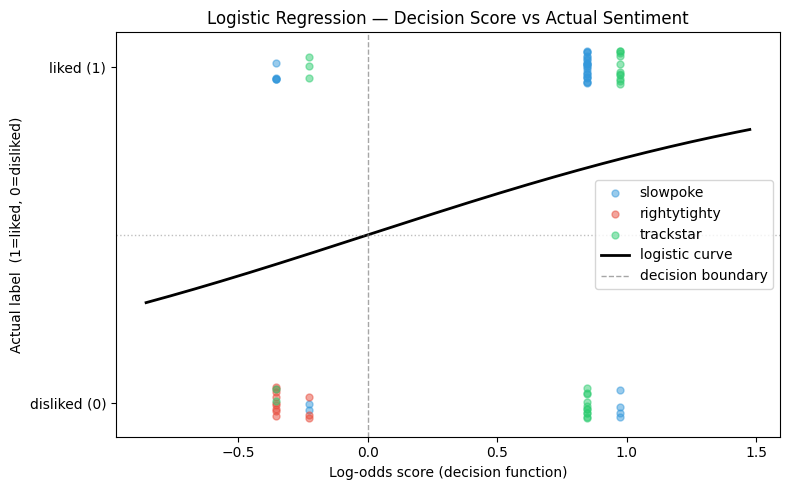

In [102]:
from scipy.special import expit  # sigmoid

fig, ax = plt.subplots(figsize=(8, 5))

user_colors = {'slowpoke': '#3498db', 'rightytighty': '#e74c3c',
               'trackstar': '#2ecc71', 'notyou': '#f39c12'}

# Scatter — x=log-odds score, y=actual label with jitter
log_odds = model.decision_function(X_test)
for key in df_users['key']:
    mask = test_fb_steps['user_key'].values == key
    if mask.sum() == 0:
        continue
    jitter = np.random.uniform(-0.05, 0.05, size=mask.sum())
    ax.scatter(log_odds[mask], y_test[mask] + jitter,
               color=user_colors[key], alpha=0.5, s=25, label=key)

# Fitted logistic curve
x_line = np.linspace(log_odds.min() - 0.5, log_odds.max() + 0.5, 300)
ax.plot(x_line, expit(x_line), color='black', linewidth=2, label='logistic curve')

# Decision boundary
ax.axvline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='decision boundary')
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

ax.set_xlabel('Log-odds score (decision function)')
ax.set_ylabel('Actual label  (1=liked, 0=disliked)')
ax.set_yticks([0, 1])
ax.set_yticklabels(['disliked (0)', 'liked (1)'])
ax.set_title('Logistic Regression — Decision Score vs Actual Sentiment')
ax.legend(loc='center right')
plt.tight_layout()
plt.show()


In [103]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, max_depth=4, random_state=42)
rf.fit(X_train, y_train)

acc_rf, auc_rf, y_pred_rf, y_pred_proba_rf = report_model(
    'Random Forest', rf, importances=('mean decrease in impurity', rf.feature_importances_)
)


Random Forest
Test accuracy : 68.5%
ROC AUC       : 0.6548

Classification report:
              precision    recall  f1-score   support

    disliked       0.67      0.52      0.58        31
       liked       0.69      0.81      0.75        42

    accuracy                           0.68        73
   macro avg       0.68      0.66      0.66        73
weighted avg       0.68      0.68      0.68        73

Feature importances (mean decrease in impurity):
              importance
feature                 
is_left_turn      0.7384
is_u_turn         0.1519
is_highway        0.1097

Per-user accuracy on test set:
  slowpoke       n= 34  acc=73.5%
  rightytighty   n= 12  acc=100.0%
  trackstar      n= 27  acc=48.1%


In [107]:
import xgboost as xgb

xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=3, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    use_label_encoder=False, eval_metric='logloss', random_state=42,
)
xgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

acc_xgb, auc_xgb, y_pred_xgb, y_pred_proba_xgb = report_model(
    'XGBoost', xgb_model, importances=('gain', xgb_model.feature_importances_)
)


/Users/maddywang/anaconda3/lib/python3.10/site-packages/xgboost/training.py:200: UserWarning: [18:03:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost
Test accuracy : 68.5%
ROC AUC       : 0.6548

Classification report:
              precision    recall  f1-score   support

    disliked       0.67      0.52      0.58        31
       liked       0.69      0.81      0.75        42

    accuracy                           0.68        73
   macro avg       0.68      0.66      0.66        73
weighted avg       0.68      0.68      0.68        73

Feature importances (gain):
              importance
feature                 
is_left_turn      0.6055
is_highway        0.2038
is_u_turn         0.1907

Per-user accuracy on test set:
  slowpoke       n= 34  acc=73.5%
  rightytighty   n= 12  acc=100.0%
  trackstar      n= 27  acc=48.1%


In [108]:
comparison = (
    pd.DataFrame({
        'Model':    ['Logistic Regression', 'Random Forest', 'XGBoost'],
        'Accuracy': [acc_lr, acc_rf, acc_xgb],
        'ROC AUC':  [auc_lr, auc_rf, auc_xgb],
    })
    .set_index('Model')
    .round(4)
)

print("=" * 50)
print("Model Comparison")
print("=" * 50)
print(comparison.to_string(), "\n")

best_acc = comparison['Accuracy'].idxmax()
best_auc = comparison['ROC AUC'].idxmax()
print(f"Best accuracy : {best_acc}  ({comparison.loc[best_acc, 'Accuracy']:.1%})")
print(f"Best ROC AUC  : {best_auc}  ({comparison.loc[best_auc, 'ROC AUC']:.4f})")


Model Comparison
                     Accuracy  ROC AUC
Model                                 
Logistic Regression    0.6849   0.6770
Random Forest          0.6849   0.6548
XGBoost                0.6849   0.6548

Best accuracy : Logistic Regression  (68.5%)
Best ROC AUC  : Logistic Regression  (0.6770)


All models converge to ~68% accuracy (reflection of the synthesized data) We don't have too many features to choose from right now so going to synthesize some features we could grab from real trip data to better tune the model. 